In [ ]:
# import
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random as rd
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from math import ceil
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.metrics import roc_curve, auc
import pylab as pl

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df_train = pd.read_csv('Hackaton_train_df.csv', index_col=0)
df_test = pd.read_csv('Hackaton_test_df.csv', index_col=0)

#df_train.shape # мы увидим информацию о размерности нашего датафрейма 
#df_train.info() # покажет информацию о размерности данных 
          # описание индекса, количество not-a-number элементов 
# показывает статистики count,mean, std, min, 25%-50%-75% percentile, max 

In [4]:
df_train.sample(15)
cols=["BS", "CALI", "DEN", "DEPT", "DT", "GR", "NEU", "PE", "RES_DEP",
       "RES_MED", "RES_MIC", "RES_SLW", "RT", "SP", "Stratigraphy",
       "Wellname"]

def chunks(l, n):
    return [l[i:i + n] for i in range(0, len(l), n)]

In [5]:
cols.remove("Wellname")
cols.remove("DEN")
cols.remove("DT")

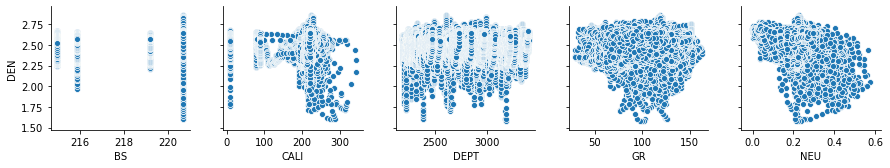

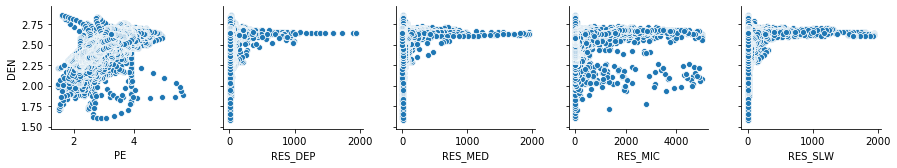

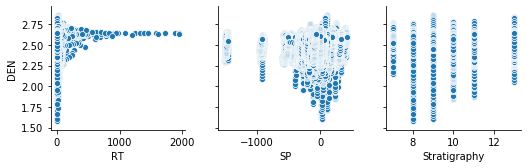

In [851]:
#Нариисовать зависимости
data = pd.concat([df_train['DEN'], df_train[cols]], axis=1)
for lst in chunks(cols, 5):
    sns.pairplot(data, y_vars=['DEN'], x_vars=lst)

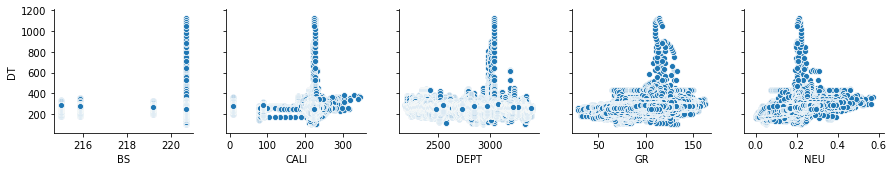

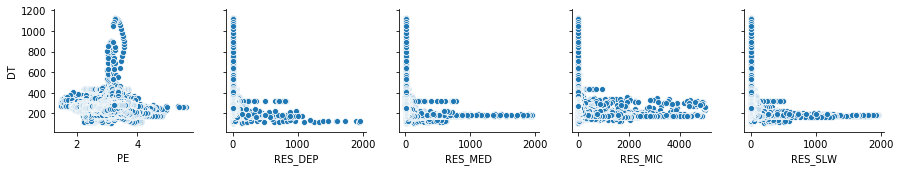

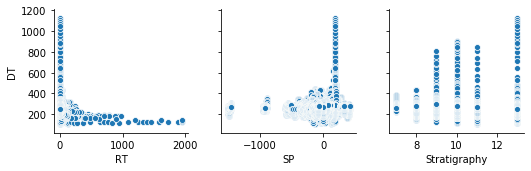

In [852]:
data = pd.concat([df_train['DT'], df_train[cols]], axis=1)
for lst in chunks(cols, 5):
    sns.pairplot(data, y_vars=['DT'], x_vars=lst)

In [6]:
missing = []
#cols=df_train.columns
for col in cols:
    cnt = df_train[col].isnull().sum() + df_test[col].isnull().sum()
    if cnt:
        missing.append(col)
        print("%s: %d" % (col, cnt))

BS: 159004
CALI: 8465
PE: 96548
RES_MIC: 158582
SP: 95791


In [7]:
drops1=["BS","DEPT","Stratigraphy"]
df_train.drop(drops1,axis=1,inplace=True)
df_test.drop(drops1,axis=1,inplace=True)

In [8]:
missing=['PE','SP','RES_MIC','CALI']

In [9]:
#Заполняем пустые ячейки в оставшихся столбцах
def impute(df, cols):
    for col in cols:
        df[col] = df[col].fillna(0)

impute(df_train, missing)
impute(df_test, missing)
print(df_train.isnull().values.any())
print(df_test.isnull().values.any())

False
False


In [846]:
print(df_train.describe())

                CALI            DEN             DT             GR  \
count  421469.000000  421469.000000  421469.000000  421469.000000   
mean      211.510179       2.469472     264.274827     100.096945   
std        34.429985       0.097699      23.369585      20.503983   
min         0.000000       1.577650     103.671898      28.848000   
25%       213.300003       2.391889     257.229004      82.762550   
50%       216.696793       2.487872     265.428986     101.242699   
75%       220.680695       2.543571     273.328613     117.142601   
max       343.950012       2.862161    1126.357056     162.472702   

                 NEU             PE        RES_DEP        RES_MED  \
count  421469.000000  421469.000000  421469.000000  421469.000000   
mean        0.211514       2.385541       8.732434       9.103197   
std         0.038718       1.200235      16.956806      23.503463   
min        -0.000143       0.000000       1.576719       1.168878   
25%         0.195738       2.3712

In [10]:
#накладываем ограничения по тесту

#outliers_more = {"NEU": 1, "PE": 10, "RES_DEP": 50, 
#            "RES_MED": 50, "RES_SLW": 50,
#           "RT": 30, "SP": 25}
#outliers_less={"SP":-400}

outliers_more= {"GR": 167.554596, "NEU": 0.588859,
                "PE": 6.622500, "RES_DEP": 1677.277954,
                "RES_MED": 1950.000000, 
                "RES_MIC": 4851.234863, 
                "RES_SLW": 1884.697998, 
                "RT": 779.697815, "SP": 236.738297}

outliers_less={"GR": 36.607670, "NEU": -0.000900,
               "PE": 1.544405, "CALI":50,
               "RES_DEP": 1.445800, "RES_MED": 1.388100, "RES_MIC": 0.439737, "RES_SLW":1.402500, 
               "RT": 1.732368, "SP":-426.505096}

def clean_outliers_more(df, outliers):
    for col in outliers:
        df = df[df[col] < outliers[col]]
    return df

def clean_outliers_less(df,outliers):
    for col in outliers:
        df = df[df[col] > outliers[col]]
    return df

print("Before cleaning: %d" % len(df_train))
df_train = clean_outliers_more(df_train, outliers_more)
df_train = clean_outliers_less(df_train, outliers_less)
print("After cleaning: %d" % len(df_train))

Before cleaning: 421469
After cleaning: 282031


In [11]:
print(df_train.describe())

                CALI            DEN             DT             GR  \
count  282031.000000  282031.000000  282031.000000  282031.000000   
mean      216.540844       2.464848     264.880578     101.164568   
std         8.302267       0.098256      24.812703      19.910899   
min        78.501503       1.605708     103.671898      38.001720   
25%       213.057800       2.384727     257.736359      83.629951   
50%       216.222305       2.484517     265.764984     102.686897   
75%       219.950699       2.540500     273.367706     117.903549   
max       319.049408       2.862161    1126.357056     162.472702   

                 NEU             PE        RES_DEP        RES_MED  \
count  282031.000000  282031.000000  282031.000000  282031.000000   
mean        0.211338       2.942355       8.900813       9.375167   
std         0.037204       0.376023      13.898948      22.420014   
min         0.015472       1.548218       1.576719       1.466510   
25%         0.196500       2.6260

In [12]:
def distplot(df, cols, ncols):
    nrows = ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 6), dpi=300)
    for idx in range(0, len(cols)):
        x = (int) (idx / ncols)
        y = (int) (idx % ncols)
        attr = cols[idx]
        sns.distplot(df[attr], fit=norm, ax=axes.item((x, y)))
    plt.tight_layout()

In [13]:
cols=df_train.columns.tolist()
print(cols)
cols.remove('Wellname')
cols.remove('DT')
cols.remove('DEN')

['CALI', 'DEN', 'DT', 'GR', 'NEU', 'PE', 'RES_DEP', 'RES_MED', 'RES_MIC', 'RES_SLW', 'RT', 'SP', 'Wellname']


In [14]:
df_skew = df_train[cols].apply(lambda x: stats.skew(x.astype('float')))
df_skew = df_skew[abs(df_skew) > 0.75]

# before transformation
#distplot(df_train, df_skew.index, 3)

#print(df_skew.index)

In [15]:
for col in df_skew.index:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])
    
#distplot(df_train, df_skew.index, 3)

['CALI', 'DEN', 'DT', 'GR', 'NEU', 'PE', 'RES_DEP', 'RES_MED', 'RES_MIC', 'RES_SLW', 'RT', 'SP']
(DEN, PE): 0.87
(RES_DEP, RES_MED): 0.97
(RES_DEP, RES_SLW): 0.93
(RES_DEP, RT): 0.97
(RES_MED, RES_MIC): 0.75
(RES_MED, RES_SLW): 0.98
(RES_MED, RT): 0.94
(RES_MIC, RES_SLW): 0.78
(RES_SLW, RT): 0.90


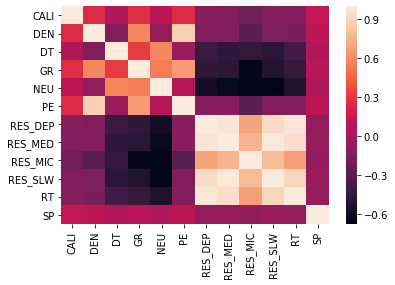

In [16]:
#Смотрим корреляцию столбцов
corr = df_train.corr()
#df_train.drop("Wellname",axis=1,inplace=True)
cols = df_train.columns.tolist()
cols.remove('Wellname')
print(cols)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        attr1 = cols[i];
        attr2 = cols[j];
        if corr[attr1][attr2] > 0.7:
            print("(%s, %s): %.2f" % (attr1, attr2, corr[attr1][attr2]))
sns.heatmap(corr);

In [17]:
drops2=["RES_DEP","RES_MED","RT","RES_SLW"]

In [18]:
df_train.drop(drops2, axis=1,inplace=True)
df_test.drop(drops2, axis=1,inplace=True)

In [19]:
print(df_train.columns.tolist())

['CALI', 'DEN', 'DT', 'GR', 'NEU', 'PE', 'RES_MIC', 'SP', 'Wellname']


In [754]:
#print(df_train['Stratigraphy'].head())

#qual_dict = {7.0: "a",8.0: "b", 9.0: "c",10.0: "d", 11.0: "e", 13: "f"}
#print(qual_dict)
#df_train['Stratigraphy'] = df_train['Stratigraphy'].map(qual_dict).astype('category')

In [755]:
#df_train['Stratigraphy'] = pd.Categorical(df_train['Stratigraphy'])

#dfDummies = pd.get_dummies(df['Stratigraphy'], prefix = 'strat')

#df_train = pd.concat([df_train, dfDummies], axis=0)
#df_test = pd.concat([df_test, dfDummies], axis=0)

#print(df_train.head())

#from sklearn.preprocessing import LabelEncoder 
#from sklearn.preprocessing import OneHotEncoder

#le =LabelEncoder() 
 
#df_train['Stratigraphy']=le.fit_transform(df_train['Stratigraphy']) 
#print(df_train['Stratigraphy'].describe())

In [20]:
# Функция для нормализации каротажей 
# Пользуемся имеенно стандартной нормировкой, чтобы избежать влияния аномалий
def normalize(df, logs):
    scaler = StandardScaler()
    df[logs] = scaler.fit_transform(df[logs])
    return df

# Функция для взятия логарифма по основанию 10 для выбранных каротажей 
def take_log10(df, logs):
    df.loc[:, logs] = np.log10(df.loc[:, logs])
    return df

In [21]:
# От скважины к скважине у нас могут меняться геологические условия, условия записи или приборы
# В связи с этим для корректной оценки алгоритмов необходимо делить данные по скважинам, а не по точкам
# Разобьем данные на тренировочную и тестовую части в пропорции 0.8 и 0.2 соответственно
train_part_size = 0.8

# Не забывайте всегда фиксировать seed для воспроизводимости результатов!
# Часть скважин будет использована для тренировки, а часть для валидации получаемого решения
rd.seed(16)
all_wells = df_train.Wellname.unique().tolist()
train_wells = rd.sample(all_wells, round(len(all_wells)*train_part_size))
train_set = df_train.loc[df_train.Wellname.isin(train_wells)]
val_set = df_train.loc[~df_train.Wellname.isin(train_wells)]

In [22]:
logs = [ 'GR', 'NEU', 'PE', 'RES_MIC','SP','CALI']

# Использование метода groupby вместе с методом apply позволяет осуществлять операции с данными поскважинно
train_set = train_set.groupby('Wellname').apply(lambda x: normalize(x, logs))
val_set = val_set.groupby('Wellname').apply(lambda x: normalize(x, logs))

In [759]:
# Приведем кривые сопротивления к логарифмическому масштабу
#train_set = take_log10(train_set, ['RES_MIC'])
#val_set = take_log10(val_set, ['RES_MIC'])

In [23]:
print(train_set.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 225237 entries, 4969 to 405362
Data columns (total 9 columns):
CALI        225237 non-null float64
DEN         225237 non-null float64
DT          225237 non-null float64
GR          225237 non-null float64
NEU         225237 non-null float64
PE          225237 non-null float64
RES_MIC     225237 non-null float64
SP          225237 non-null float64
Wellname    225237 non-null object
dtypes: float64(8), object(1)
memory usage: 17.2+ MB
None


In [820]:
train_set.isnull().values.any()

False

In [24]:
# evaluate with k-fold cross validation, and report RMSE score
def evaluate(model, X, y, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=2)
    y_pr = np.zeros((X.shape[0],))
    for train_index, test_index in kf.split(X):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        y_tr, y_te = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_tr, y_tr)
        y_pr[test_index] = model.predict(X_te)
    err = sqrt(mean_squared_error(y_pr, y))
    print("RMSE: %.5f" % err)
def coef(model, X):
    for l, r in sorted(zip(X.columns, model.coef_), key=lambda x: abs(x[1]), reverse=True)[:5]:
        print("(%s, %.5f)" % (l, r))
def print_params(est, X, y, n=100):
    print("Chosen parameter on %d datapoints: %s" % 
          (n,est.fit(X[:n], y[:n]).best_params_))
def generate_submission(model, X):
    suffix = model.__class__.__name__.lower()
    y_pr = model.predict(X)
    result = np.exp(y_pr)
    submission = pd.DataFrame({'Id': X.index.values, 'SalePrice': result})
    submission.to_csv("submission_" + suffix + ".csv", index=None)

In [25]:
# Разобьем данные тренировочной и тестовой частей на матрицу признаков и вектор классов
X_train = train_set.drop(['DEN', 'DT', 'Wellname'], axis=1)
Y_train = train_set[['DEN','DT']]
y_train_den = train_set['DEN']
y_train_dt = train_set['DT']

X_val = val_set.drop(['DEN', 'DT', 'Wellname'], axis=1)
Y_val=val_set[['DEN','DT']]
y_val_den = val_set['DEN']
y_val_dt = val_set['DT']

# settings
nJobs = psutil.cpu_count()
kFold = 10

#X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.8)

In [211]:
#fig, axes = plt.subplots(ncols=2, figsize=(10,4))
#TestModels.R2_Y1.plot(ax=axes[0], kind='bar', title='R2_Y1')
#TestModels.R2_Y2.plot(ax=axes[1], kind='bar', color='green', title='R2_Y2')

In [871]:
#Нейронная сеть
from sklearn.neural_network import MLPRegressor

#solvers = ['lbfgs', 'sgd', 'adam']
solvers=['adam']
params = {'learning_rate_init': 0.2, 'max_iter': 5000, 'alpha': 1e-5,
          'momentum': 0.9, 'learning_rate': 'constant'}
mlp_den = MLPRegressor(**params)
mlp_dt = MLPRegressor(**params)
est1 = GridSearchCV(mlp_den, param_grid={ "solver": solvers})
est2 = GridSearchCV(mlp_dt, param_grid={ "solver": solvers})

print_params(est1, X_train, y_train_den, 400)
print_params(est2, X_train, y_train_dt, 400)

Chosen parameter on 400 datapoints: {'solver': 'adam'}
Chosen parameter on 400 datapoints: {'solver': 'adam'}


In [872]:
# cross validation
evaluate(mlp_den, X_train, y_train_den, kFold)
evaluate(mlp_den, X_train, y_train_dt, kFold)
den_pred_mlp=mlp_den.predict(X_val)
dt_pred_mlp=mlp_dt.predict(X_val)

RMSE: 0.07704
RMSE: 29.04431


NotFittedError: This MLPRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [938]:
#####################################Случайный лес
n_estimators = [100, 200, 400, 800, 1600]
max_features = [0.05, 0.15, 0.30, 0.60, 0.80, "sqrt", "log2", None]
max_depths = [5, 10]
min_samples_leaves = [1, 2, 4]
params = {"n_jobs": nJobs}
rf_den = RandomForestRegressor(**params)
rf_dt = RandomForestRegressor(**params)
est1 = GridSearchCV(rf_den, param_grid={"n_estimators": n_estimators, 
                                   "max_features": max_features,
                                   "max_depth": max_depths,
                                   "min_samples_leaf": min_samples_leaves
                                  })
est2=GridSearchCV(rf_dt, param_grid={"n_estimators": n_estimators, 
                                   "max_features": max_features,
                                   "max_depth": max_depths,
                                   "min_samples_leaf": min_samples_leaves
                                  })
print_params(est, X_train, y_train_den, 400)

Chosen parameter on 400 datapoints: {'alpha': 1.0}


In [939]:
params = {"n_jobs": nJobs, 'max_depth': 20, 'max_features': 0.3, 
          'min_samples_leaf': 1, 'n_estimators': 800}
#cross validation
evaluate(rf_den, X_train, y_train_den, kFold)
evaluate(rf_dt,X_train,y_train_dt,kFold)
den_pred_rf=ridge_den.predict(X_val)
dt_pred_rf=ridge_dt.predict(X_val)

RMSE: 0.03246
RMSE: 15.18558


In [26]:
rd.seed(15)
#############################################RIDGE REGRESSION
from sklearn.linear_model import Ridge
params = {'max_iter': 50000}
ridge_den = Ridge(**params)
ridge_dt = Ridge(**params)
est1 = GridSearchCV(ridge_den, param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]})
est2 = GridSearchCV(ridge_dt, param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]})
print_params(est1, X_train, y_train_den, 100)
print_params(est2, X_train, y_train_dt, 100)

Chosen parameter on 100 datapoints: {'alpha': 10.0}
Chosen parameter on 100 datapoints: {'alpha': 1.0}


In [27]:
params1 = {'alpha': 10.0, 'max_iter': 50000}
params2={'alpha': 0.01, 'max_iter': 50000}

ridge_den = Ridge(**params1)
ridge_dt=Ridge(**params2)
# cross validation
evaluate(ridge_den, X_train, y_train_den, kFold)
evaluate(ridge_dt, X_train, y_train_dt, kFold)
den_pred=ridge_den.predict(X_val)
dt_pred=ridge_dt.predict(X_val)

RMSE: 0.04653
RMSE: 18.84426


In [901]:
##############################################LASSO REGRESSION
from sklearn.linear_model import Lasso
params = {'max_iter': 50000}
lasso_den = Lasso(**params)
lasso_dt=Lasso(**params)
est1 = GridSearchCV(lasso_den, param_grid={"alpha": np.arange(0.0005, 0.001, 0.00001)})
est2 = GridSearchCV(lasso_dt, param_grid={"alpha": np.arange(0.0005, 0.001, 0.00001)})
print_params(est1, X_train, y_train_den, 100)
print_params(est2, X_train, y_train_dt, 100)

Chosen parameter on 100 datapoints: {'alpha': 0.0009900000000000013}
Chosen parameter on 100 datapoints: {'alpha': 0.0009900000000000013}


In [902]:
params = {'alpha': 0.0001, 'max_iter': 50000}
lasso = Lasso(**params)
# cross validation
evaluate(lasso_den, X_train, y_train_den, kFold)
evaluate(lasso_dt, X_train, y_train_dt, kFold)
den_pred=lasso_den.predict(X_val)
dt_pred=lasso_dt.predict(X_val)

RMSE: 0.09887
RMSE: 18.89949


In [34]:
###############################Support vector regression########################
from sklearn.svm import SVR
params = {"kernel": "linear"}
svr1 = SVR(**params)
svr2= SVR(**params)
est1 = GridSearchCV(svr1, param_grid={"C": [0.001, 0.01, 0.1, 1.0, 10.0], 
                                    "epsilon": [0.001, 0.01, 0.1, 1.0, 10.0]})
est2 = GridSearchCV(svr2, param_grid={"C": [0.001, 0.01, 0.1, 1.0, 10.0], 
                                    "epsilon": [0.001, 0.01, 0.1, 1.0, 10.0]})
print_params(est1, X_train, y_train_den, 100)
print_params(est2, X_train, y_train_dt, 100)

Chosen parameter on 100 datapoints: {'C': 0.001, 'epsilon': 0.001}
Chosen parameter on 100 datapoints: {'C': 1.0, 'epsilon': 0.001}


In [ ]:
params = {"kernel": "linear", "C": 0.01}
svr1 = SVR(**params)
svr2=SVR(**params)
# cross validation
evaluate(svr1, X_train, y_train_den, kFold)
evaluate(svr2,X_train,y_train_dt,kFold)
den_pred=svr1.predict(X_val)
dt_pred=svr2.predict(X_val)

In [ ]:
##############################################ADAPTIVE BOOSTING
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
max_features = [0.05, 0.15, 0.30, 0.60, 0.80, "sqrt", "log2", None]
base_estimators = []
for fea in max_features:
    base_estimators.append(DecisionTreeRegressor(max_features=fea))
n_estimators = [3000]
learning_rates = [0.05]
params = {}
ab = AdaBoostRegressor(**params)
est = GridSearchCV(ab, param_grid={"base_estimator": base_estimators, 
                                   "n_estimators": n_estimators, 
                                   "learning_rate": learning_rates})
print_params(est, X_train, y_train, 400)

In [ ]:
base_estimator = DecisionTreeRegressor(max_features=0.3)
params = {"base_estimator": base_estimator, "n_estimators": 3000, "learning_rate": 0.05}
ab = AdaBoostRegressor(**params)
# cross validation
evaluate(ab, X_train, y_train, kFold)

In [ ]:
##############################################GRADIENT BOOSTED DECISION TREE

from sklearn.ensemble import GradientBoostingRegressor
max_features = [0.05, 0.15, 0.30, 0.60, 0.80, "sqrt", "log2", None]
params = {
    'n_estimators': 3000,
    'learning_rate': 0.05,
    'max_depth': 3,
    'min_samples_leaf': 15,
    'min_samples_split': 10,
    'loss': 'huber'
}
gbdt = GradientBoostingRegressor(**params)
est = GridSearchCV(gbdt, param_grid={"max_features": max_features})
print_params(est, X_train, y_train, 400)

In [ ]:
params = {
    'n_estimators': 3000,
    'learning_rate': 0.05,
    'max_depth': 3,
    'min_samples_leaf': 15,
    'min_samples_split': 10,
    'loss': 'huber',
    'max_features': 'log2'
}
gbdt = GradientBoostingRegressor(**params)
# cross validation
evaluate(gbdt, X_train, y_train, kFold)

In [28]:
######################################### Функция для поскважинного расчета r2 метрики
def r2_per_well_score(y_true, y_pred, well_array):
    temp_df = pd.DataFrame(data=np.column_stack([y_true, y_pred, well_array]), columns=['y_true', 'y_pred', 'wellname'])
    temp_df_score = temp_df.groupby('wellname').apply(lambda x: r2_score(x['y_true'], x['y_pred']))
    return temp_df_score

In [29]:
r2_per_well_den = r2_per_well_score(y_val_den, den_pred, val_set['Wellname'])
r2_per_well_dt = r2_per_well_score(y_val_dt, dt_pred, val_set['Wellname'])
r2_per_well=pd.DataFrame()
r2_per_well["DEN"]=r2_per_well_den
r2_per_well['DT']=r2_per_well_dt
print(r2_per_well)

               DEN        DT
wellname                    
0_24      0.825471  0.606189
0_3       0.671037 -0.043059
1_155     0.654165  0.747463
1_167     0.879658  0.414626
1_168     0.900094  0.521992
1_235     0.783470  0.724048
1_239     0.412310  0.633306
2_193     0.810072  0.740862
2_196     0.730774  0.627278
2_199     0.733719  0.739145
2_203     0.804718  0.825071
2_206     0.773721  0.795198
2_211     0.744206  0.773178
2_212     0.756666  0.444357
2_218     0.755646  0.719254
2_222     0.826244  0.656842
2_259     0.824105  0.803651
2_263     0.834920  0.817419
2_268     0.784151  0.705505
2_270     0.805210  0.545393
2_310     0.631188  0.501969
2_313     0.838051  0.703401
2_326     0.738879  0.290754
2_349     0.810990  0.650353
2_378     0.818489 -1.409884
2_384     0.832468  0.794340
2_399     0.895549 -0.175477
2_439     0.753269  0.791808
2_442     0.901522  0.809511
2_444     0.857398  0.807376
2_452     0.843373  0.581119
2_457     0.776497  0.796692
2_458     0.75

In [30]:
# Возьмем средние значения r2 по всем скважинам для каждого целевого признака
r2_den_mean = r2_per_well_den.mean() 
r2_dt_mean = r2_per_well_dt.mean()
print(r2_den_mean,r2_dt_mean)

0.7838773897588001 0.5792161857273633


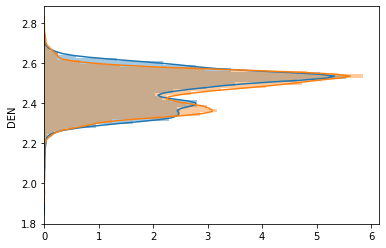

In [31]:
y_val_den.head()
sns.distplot(y_val_den,vertical=True)
sns.distplot(den_pred,vertical=True)

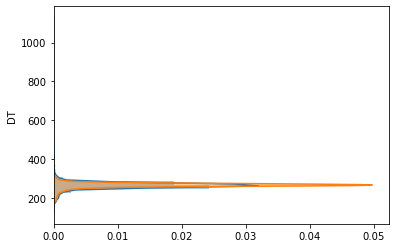

In [909]:
sns.distplot(y_val_dt,vertical=True)
sns.distplot(dt_pred,vertical=True)

In [377]:
# В качестве обучающей выборки будет использоваться вся тренировочная часть
X = df_train[['GR', 'NEU','PE', 'RT','SP', 'RES_MIC', 'Wellname']]
y_den = df_train['DEN']
y_dt = df_train['DT']

In [378]:
# Нормализуем каротаж по аналогии с предыдущими шагами
X = X.groupby('Wellname').apply(lambda x: normalize(x, logs))

# Удалим информацию про названия скважин
X.drop(columns=['Wellname'], inplace=True)

In [ ]:
# В качестве классификаторов будем использовать модели с наилучшими параметрами
# В данном случае, базовое решение - линейная регрессия без регуляризации, поэтому параметров нет 



In [ ]:
# Имя вашей команды
your_name = 'Baseline'